# 1. Set up the notebook

Do imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import Image
from ae483.tools import *
from ae483.mytools import *

# 2. Estimate the mass

Find the mass $m$ of the drone in kilograms.

In [2]:
m = 32*1e-3 # <-- FIXME

Find a worst-case bound $\Delta m$ on the uncertainty of your estimate. This bound should be chosen so that the true mass is guaranteed to be in the interval $[m - \Delta m, m + \Delta m]$.

In [3]:
delta_m = 1*1e-3 # <-- FIXME

# 3. Estimate the moment of inertia about the $x_B$-axis

Show a picture of your rig (change the file name or file extension as appropriate).

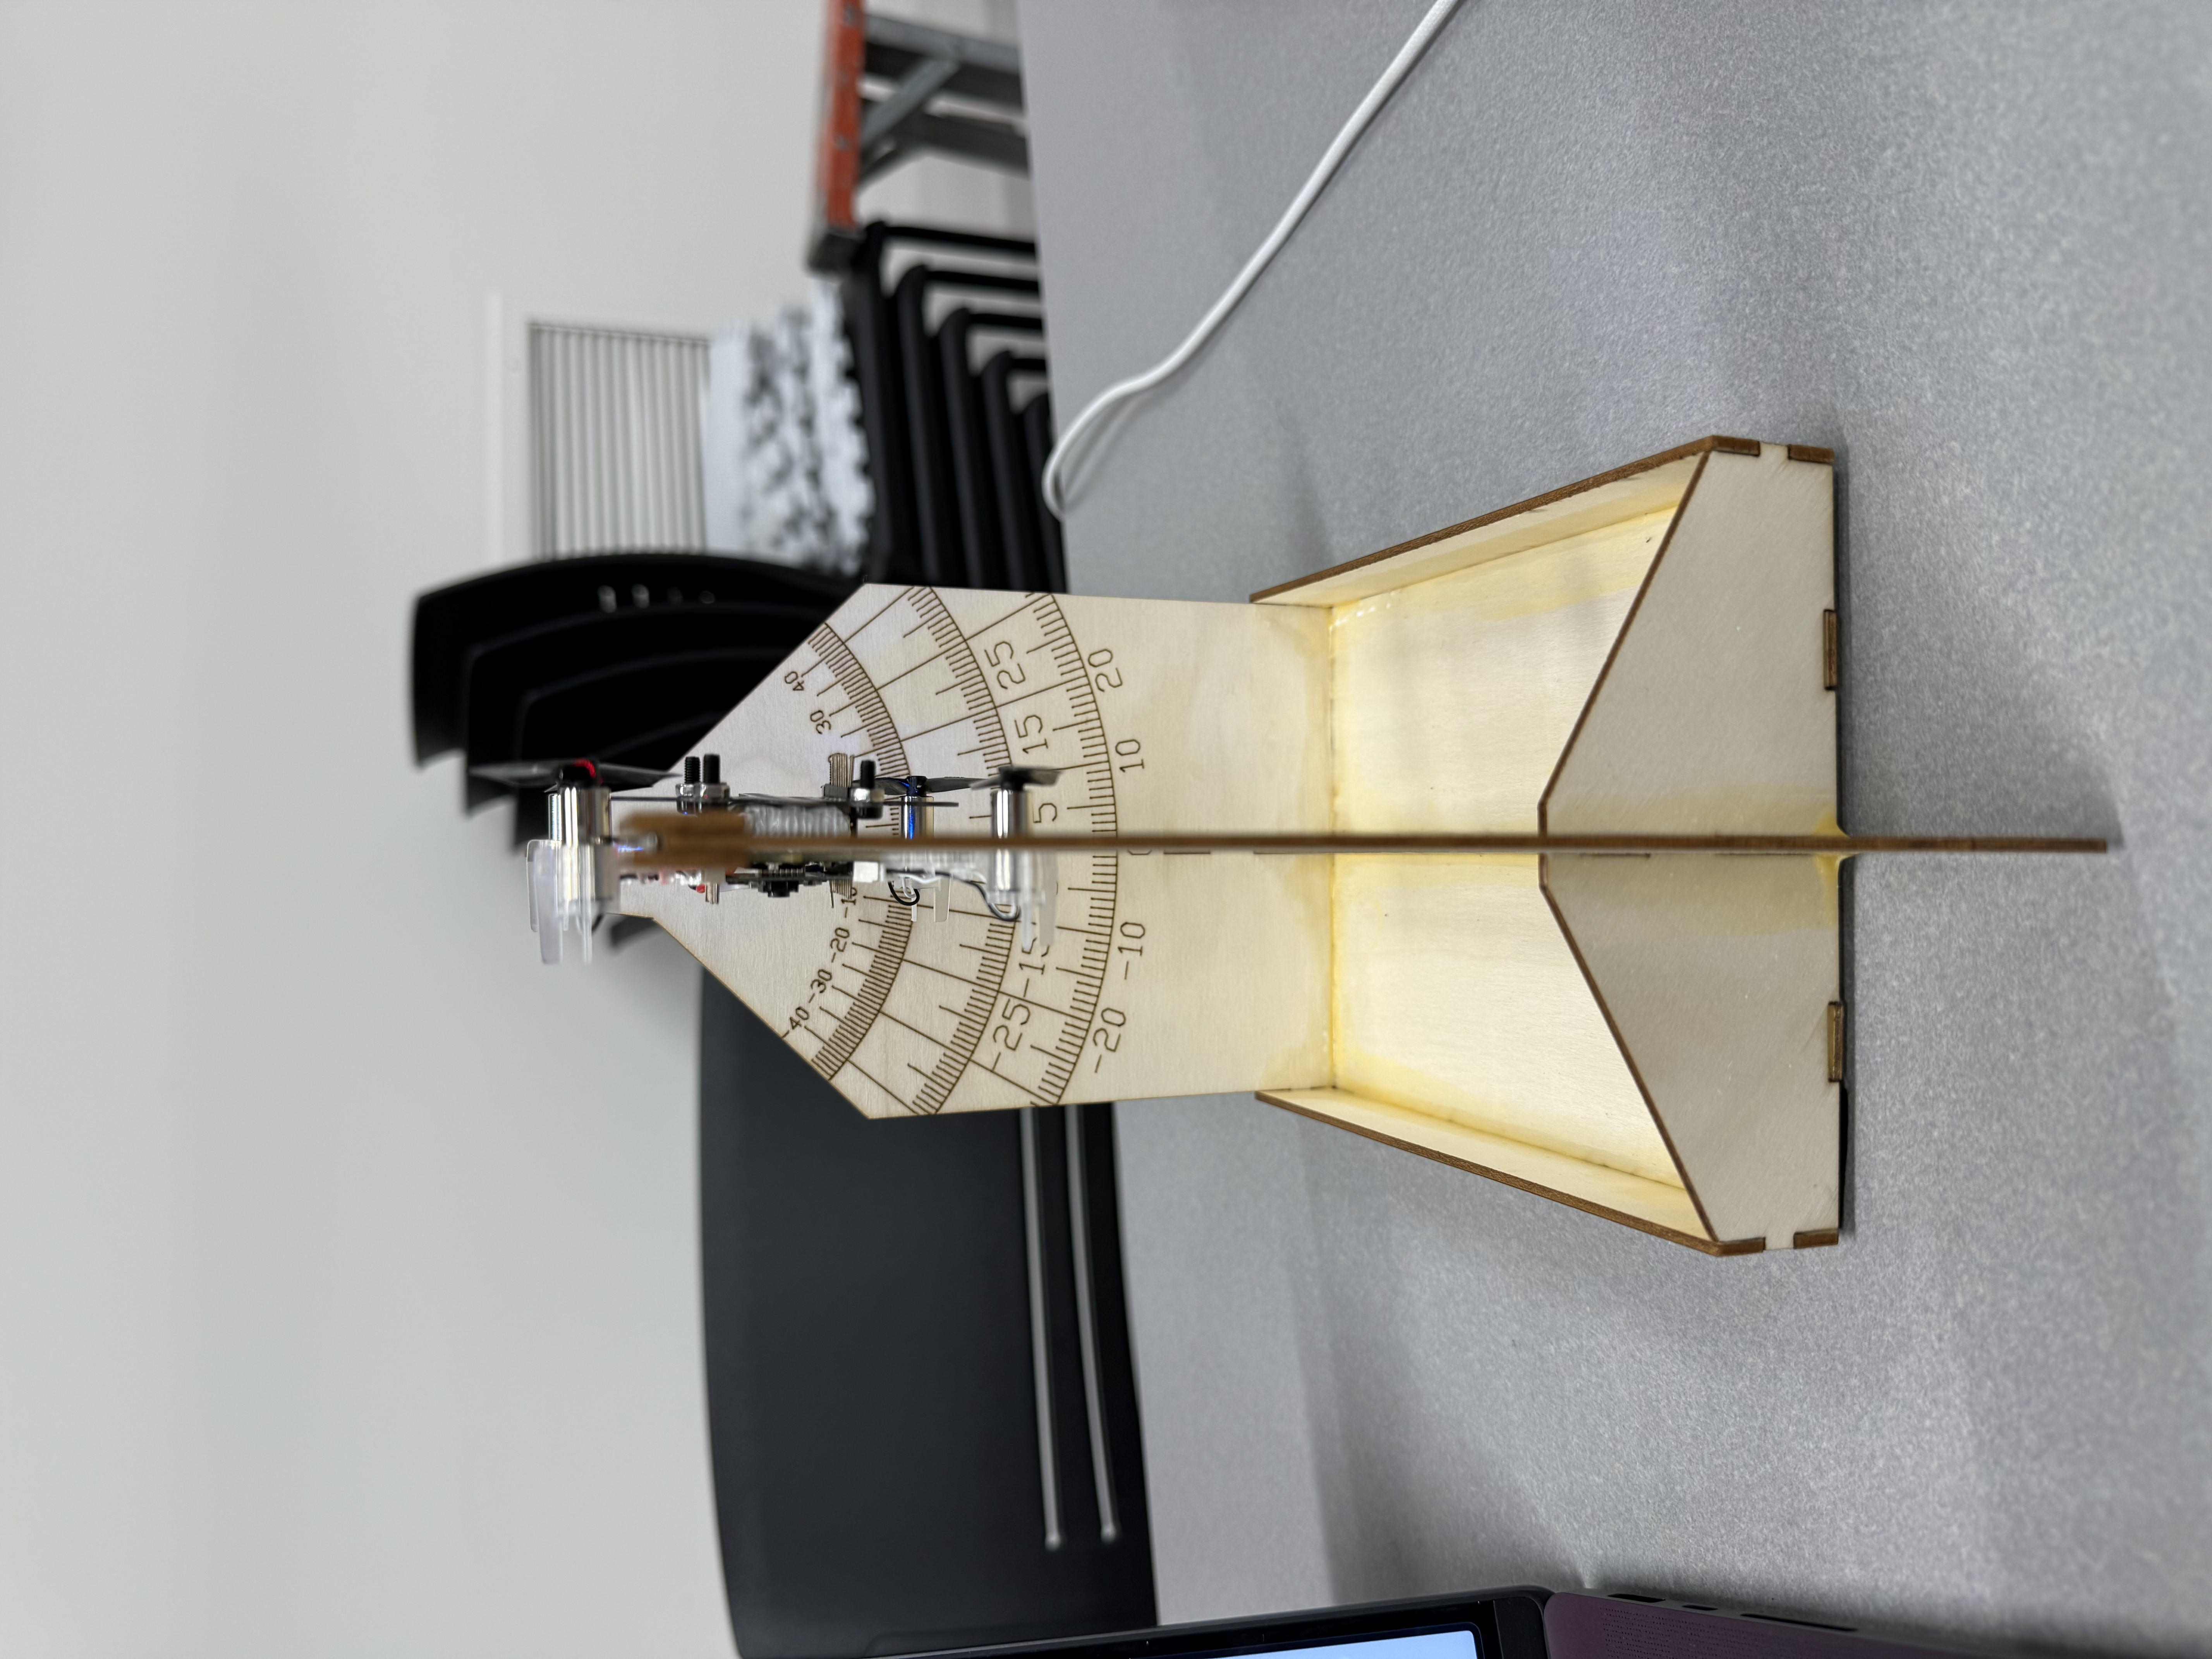

In [4]:
Image(filename='x_rig.jpg', width=480)

Find the distance in meters between the axis of rotation and the center of mass.

In [5]:
r = 2.9*1e-2 # <-- FIXME

Find a worst-case bound $\Delta r$ on the uncertainty of your estimate.

In [6]:
delta_r = 0.2*1e-2 # <-- FIXME

Load, resample, and parse data to get time and the three components of angular velocity (in radians / second).

Remember that `resample_drone_data` has two optional arguments that allow you to discard data at the start and end of the experiment. You may find these arguments useful, since you will likely find that some of the data at the start and end of your experiment are garbage.

In [7]:
# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('x_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=1.,    # <-- FIXME
    t_max_offset=0.,    # <-- FIXME
)

# Parse data
t = data_drone['time']
w_x = np.deg2rad(data_drone['gyro.x'])
w_y = np.deg2rad(data_drone['gyro.y'])
w_z = np.deg2rad(data_drone['gyro.z'])

Plot all three components of angular velocity. You are trying to estimate the moment of inertia about the $x$ axis. The component of angular velocity about this axis should be large, and the components of angular velocity about the other two axes should be negligibly small. It is important to check this. (Please also check if you have data at the start and end of the experiment that need to be discarded.)

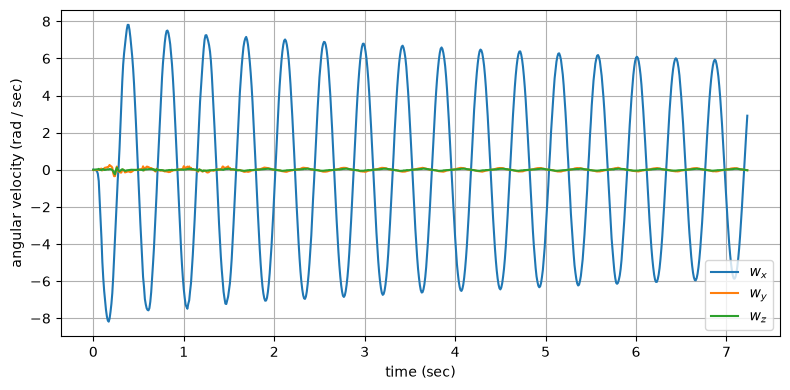

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_x, label='$w_x$')
ax.plot(t, w_y, label='$w_y$')
ax.plot(t, w_z, label='$w_z$')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

You should find that `w_x` is oscillatory. The period is the peak-to-peak time. You could measure the period by hand, but it is easier to automate this process, particularly if you want to average your estimate of the period over many oscillations.

Here is one way to do it:

* Find the index $i_k$ of each peak $k\in\{0, \dotsc, n-1\}$ in your data.
* Find the time $t_k$ at each peak for $k\in\{0, \dotsc, n-1\}$.
* Find the difference $T_k = t_{k+1} - t_k$ between consecutive peak times for $k \in \{0, \dotsc, n-2\}$.
* Find the mean difference: $$\widehat{T} = \dfrac{1}{n-1} \sum_{k=0}^{n-2} T_k.$$ This is an estimate of the oscillation period.

Here is one way to implement this in code, using [scipy.signal.find_peaks](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html):

In [9]:
# Find the index of each peak (increase "prominence" if you get bad results)
peaks = find_peaks(w_x, prominence=0)
i_peaks = peaks[0]

# Find the time at each peak
t_peaks = t[i_peaks]

# Find w_x at each peak (for visualization)
w_x_peaks = w_x[i_peaks]

# Find the difference between consecutive peak times
#
# Note:
#
#  t_peaks[1:] means t_peaks without the first element
#  t_peaks[:-1] means t_peaks without the last element
#
# So, t_peaks[1:] - t_peaks[:-1] produces the following array:
#
#  [t_peaks[1]-t_peaks[0], t_peaks[0]-t_peaks[1], ...]
#
t_diff = t_peaks[1:] - t_peaks[:-1]

# Find the mean difference as an estimate of the oscillation period
T = np.mean(t_diff)

# Print the estimate
print(f'T = {T:.4f} sec')

T = 0.4327 sec


Sanity check — plot the peaks. (**FIXME: How do you know these results are good?**)

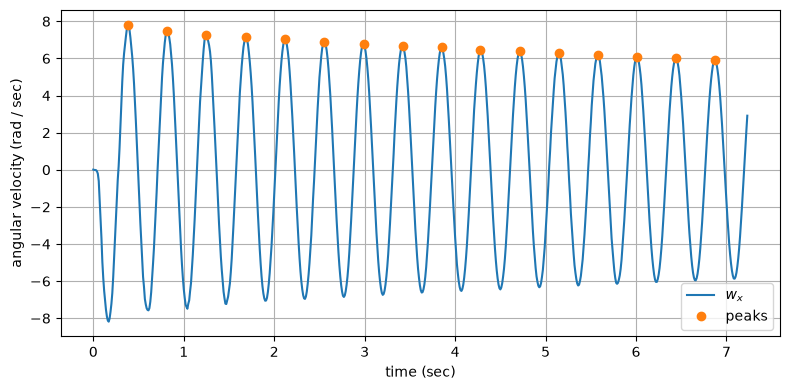

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_x, label='$w_x$')
ax.plot(t_peaks, w_x_peaks, '.', markersize=12, label='peaks')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

Sanity check — plot the differences between consecutive peak times. (**FIXME: How do you know these results are good?**)

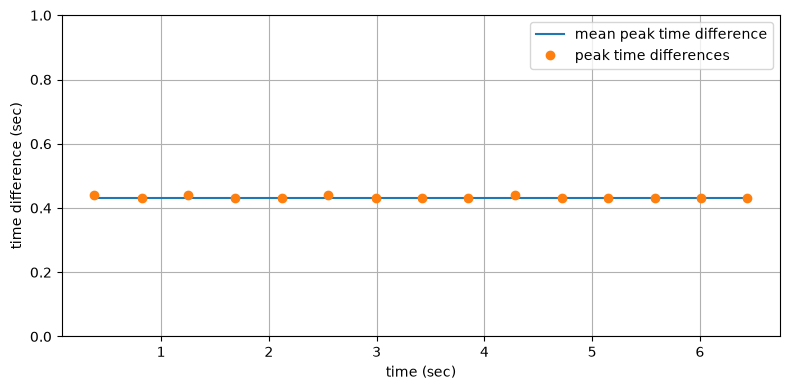

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t_peaks[:-1], T * np.ones_like(t_peaks[:-1]), label='mean peak time difference')
ax.plot(t_peaks[:-1], t_diff, '.', markersize=12, label='peak time differences')
ax.set_ylim(0., 1.)
ax.set_xlabel('time (sec)')
ax.set_ylabel('time difference (sec)')
ax.grid()
ax.legend()
plt.show()

Find a worst-case bound $\Delta T$ on the uncertainty of your estimate.

In [12]:
delta_T = np.max(t_diff - T) # <-- FIXME
print(f'delta_T = {delta_T:.4f} sec')

delta_T = 0.0073 sec


Find the moment of inertia about the $x$ axis.

In [13]:
g = 9.81 # m/s^2

In [14]:
J_x = (m*g*r) / (2 * np.pi / T)**2 - m * r**2
print(f'J_x = {J_x:.6f} kg m^2')

J_x = 0.000016 kg m^2


Find a worst-case bound $\Delta J_x$ on the uncertainty in your estimate.

In [15]:
# J_x = (m*g*r) / (2*pi/T)**2 - m*r**2, so propagate delta_m, delta_r, delta_T through
# the partial derivatives of J_x with respect to m, r, and T
dJ_dm = (g * r * T**2) / (4 * np.pi**2) - r**2
dJ_dr = (g * m * T**2) / (4 * np.pi**2) - 2 * m * r
dJ_dT = (g * m * r * T) / (2 * np.pi**2)

delta_J_x = np.abs(dJ_dm) * delta_m + np.abs(dJ_dr) * delta_r + np.abs(dJ_dT) * delta_T
print(f'delta_J_x = {delta_J_x:.6f} kg m^2')

delta_J_x = 0.000003 kg m^2


# 4. Estimate the moment of inertia about the $y_B$-axis

Add cells here to repeat the same process as above...

In [16]:
# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('y_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=0.,    # <-- FIXME
    t_max_offset=0.,    # <-- FIXME
)

# Parse data
t = data_drone['time']
w_x = np.deg2rad(data_drone['gyro.x'])
w_y = np.deg2rad(data_drone['gyro.y'])
w_z = np.deg2rad(data_drone['gyro.z'])

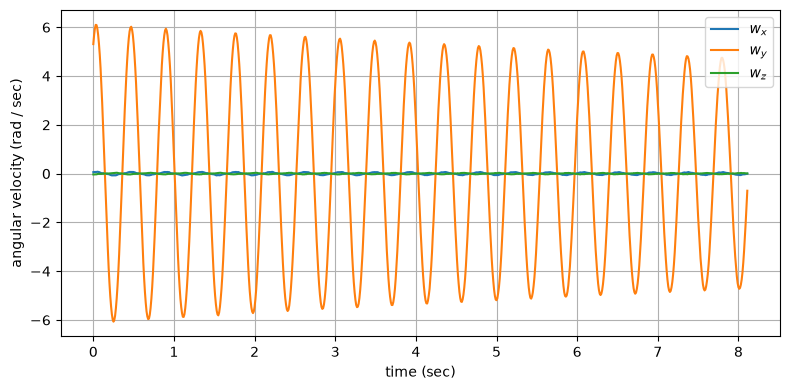

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_x, label='$w_x$')
ax.plot(t, w_y, label='$w_y$')
ax.plot(t, w_z, label='$w_z$')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

In [18]:
# Find the index of each peak (increase "prominence" if you get bad results)
peaks = find_peaks(w_y, prominence=0)
i_peaks = peaks[0]

# Find the time at each peak
t_peaks = t[i_peaks]

# Find w_y at each peak (for visualization)
w_y_peaks = w_y[i_peaks]

# Find the difference between consecutive peak times
#
# Note:
#
#  t_peaks[1:] means t_peaks without the first element
#  t_peaks[:-1] means t_peaks without the last element
#
# So, t_peaks[1:] - t_peaks[:-1] produces the following array:
#
#  [t_peaks[1]-t_peaks[0], t_peaks[0]-t_peaks[1], ...]
#
t_diff = t_peaks[1:] - t_peaks[:-1]

# Find the mean difference as an estimate of the oscillation period
T = np.mean(t_diff)

# Print the estimate
print(f'T = {T:.4f} sec')

T = 0.4317 sec


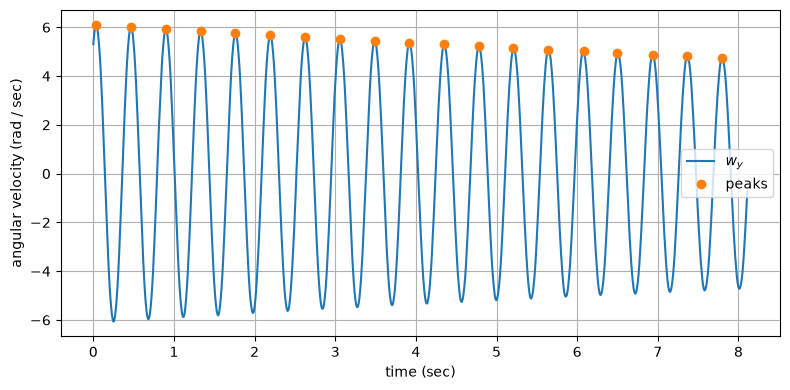

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_y, label='$w_y$')
ax.plot(t_peaks, w_y_peaks, '.', markersize=12, label='peaks')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

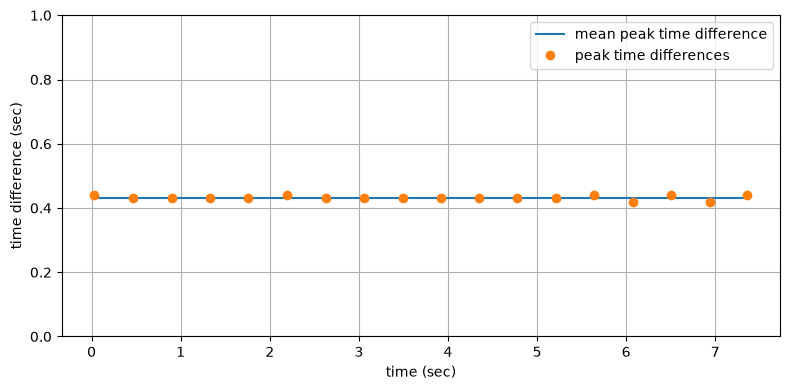

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t_peaks[:-1], T * np.ones_like(t_peaks[:-1]), label='mean peak time difference')
ax.plot(t_peaks[:-1], t_diff, '.', markersize=12, label='peak time differences')
ax.set_ylim(0., 1.)
ax.set_xlabel('time (sec)')
ax.set_ylabel('time difference (sec)')
ax.grid()
ax.legend()
plt.show()

In [21]:
delta_T = np.max(t_diff - T) # <-- FIXME
print(f'delta_T = {delta_T:.4f} sec')

delta_T = 0.0083 sec


In [22]:
J_y = (m*g*r) / (2 * np.pi / T)**2 - m * r**2

# Same J(m, r, T) formula as above (same rig, so same r and delta_r), evaluated
# with this section's T and delta_T
dJ_dm = (g * r * T**2) / (4 * np.pi**2) - r**2
dJ_dr = (g * m * T**2) / (4 * np.pi**2) - 2 * m * r
dJ_dT = (g * m * r * T) / (2 * np.pi**2)

delta_J_y = np.abs(dJ_dm) * delta_m + np.abs(dJ_dr) * delta_r + np.abs(dJ_dT) * delta_T
print(f'delta_J_y = {delta_J_y:.6f} kg m^2')

delta_J_y = 0.000003 kg m^2


# 5. Estimate the moment of inertia about the $z_B$-axis

Add cells here to repeat the same process as above...

In [23]:
# Load data
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('z_data.json')

# Resample data
data_drone = resample_data_drone(
    raw_data_drone,
    t_min_offset=0.,    # <-- FIXME
    t_max_offset=0.,    # <-- FIXME
)

# Parse data
t = data_drone['time']
w_x = np.deg2rad(data_drone['gyro.x'])
w_y = np.deg2rad(data_drone['gyro.y'])
w_z = np.deg2rad(data_drone['gyro.z'])

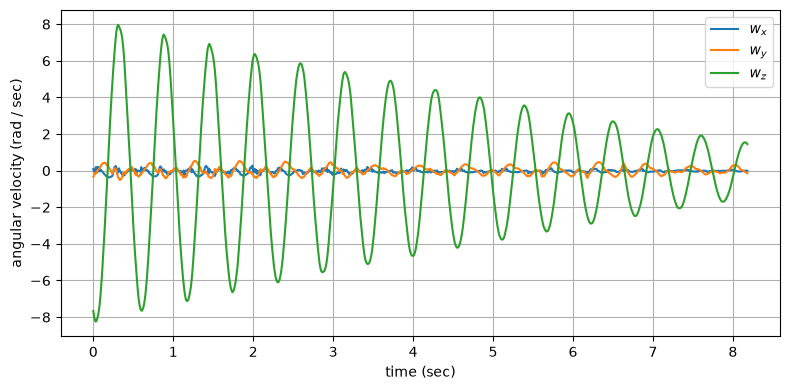

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_x, label='$w_x$')
ax.plot(t, w_y, label='$w_y$')
ax.plot(t, w_z, label='$w_z$')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

In [25]:
# Find the index of each peak (increase "prominence" if you get bad results)
peaks = find_peaks(w_z, prominence=0)
i_peaks = peaks[0]

# Find the time at each peak
t_peaks = t[i_peaks]


# Find w_z at each peak (for visualization)
w_z_peaks = w_z[i_peaks]

# Find the difference between consecutive peak times
#
# Note:
#
#  t_peaks[1:] means t_peaks without the first element
#  t_peaks[:-1] means t_peaks without the last element
#
# So, t_peaks[1:] - t_peaks[:-1] produces the following array:
#
#  [t_peaks[1]-t_peaks[0], t_peaks[0]-t_peaks[1], ...]
#
t_diff = t_peaks[1:] - t_peaks[:-1]

# Find the mean difference as an estimate of the oscillation period
T = np.mean(t_diff)

# Print the estimate
print(f'T = {T:.4f} sec')

T = 0.5600 sec


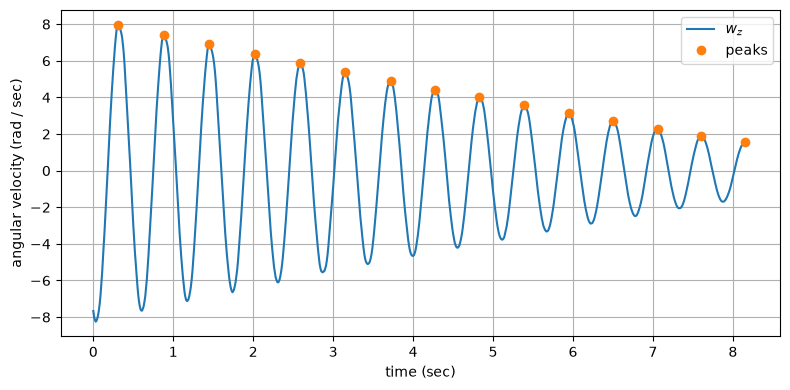

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t, w_z, label='$w_z$')
ax.plot(t_peaks, w_z_peaks, '.', markersize=12, label='peaks')
ax.set_xlabel('time (sec)')
ax.set_ylabel('angular velocity (rad / sec)')
ax.legend()
ax.grid()
plt.show()

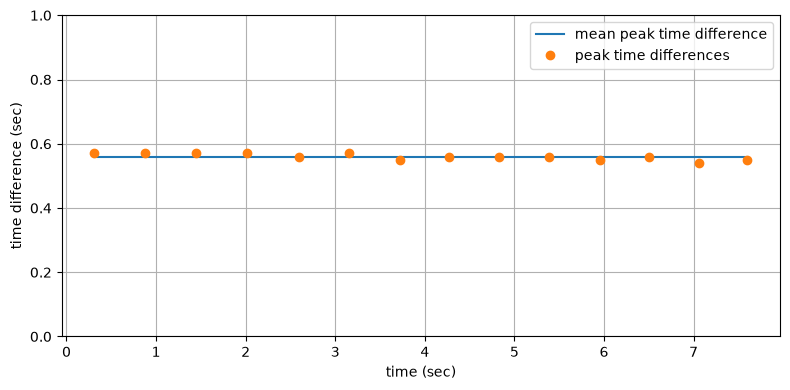

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), tight_layout=True)
ax.plot(t_peaks[:-1], T * np.ones_like(t_peaks[:-1]), label='mean peak time difference')
ax.plot(t_peaks[:-1], t_diff, '.', markersize=12, label='peak time differences')
ax.set_ylim(0., 1.)
ax.set_xlabel('time (sec)')
ax.set_ylabel('time difference (sec)')
ax.grid()
ax.legend()
plt.show()

In [28]:
delta_T = np.max(t_diff - T) # <-- FIXME
print(f'delta_T = {delta_T:.4f} sec')

delta_T = 0.0100 sec


In [29]:
r_z = 1.5*1e-2
delta_r_z = 0.2*1e-2
J_z = (m*g*r_z) / (2 * np.pi / T)**2 - m * r_z**2

# Same J(m, r, T) formula as above (same rig, so same r and delta_r), evaluated
# with this section's T and delta_T
dJ_dm = (g * r_z * T**2) / (4 * np.pi**2) - r_z**2
dJ_dr = (g * m * T**2) / (4 * np.pi**2) - 2 * m * r_z
dJ_dT = (g * m * r_z * T) / (2 * np.pi**2)

delta_J_z = np.abs(dJ_dm) * delta_m + np.abs(dJ_dr) * delta_r_z + np.abs(dJ_dT) * delta_T
print(f'delta_J_z = {delta_J_z:.6f} kg m^2')

delta_J_z = 0.000005 kg m^2


# 6. Summarize and discuss the results

### Summary of results

In [30]:
print(f'm = {m:.4f} +/- {delta_m:.4f} kg')
print(f'J_x = {J_x:.2e} +/- {delta_J_x:.2e} kg m^2')
print(f'J_y = {J_y:.2e} +/- {delta_J_y:.2e} kg m^2')
print(f'J_z = {J_z:.2e} +/- {delta_J_z:.2e} kg m^2')

m = 0.0320 +/- 0.0010 kg
J_x = 1.63e-05 +/- 2.71e-06 kg m^2
J_y = 1.61e-05 +/- 2.91e-06 kg m^2
J_z = 3.02e-05 +/- 5.35e-06 kg m^2


### Analysis of uncertainty

**Modify the text in this cell** to answer the following questions:
* Which computed quantities ($J_x$, $J_y$, $J_z$) are the most uncertain?

$J_z$ is the most uncertain.

* Which measured quantities ($m$, $r$, $T$) contribute the most to uncertainty in the computed quantities?

$r$ contributes the most to uncertainty in the computed quantities.

* What assumptions were made and to what extent were these assumptions violated?

One assumption made was that $r$ is measured from the direct center of the drone without consideration for where the acutal CG of the drone is located. This assumption is likely violated by where the CG is actually located on teh drone due to battery wires offseting the CG towards the -x direction.

* What sources of error might not be captured in your analysis of uncertainty?

The drone's own measurement of angular velocity might be a source of error that is not captured in our analysis of uncertainty.

### Ways to improve the results

**Modify the text in this cell** to propose at least one way in which the experiments or the analysis could be improved to get estimates of mass and moments of inertia that are more accurate (i.e., less uncertain). You could suggest improvements to your current method of approach, but you are also welcome to suggest a completely different method of approach.

A precise measurement of the drone's CG will improve the drone's $r$ measurement, which can be achieved via the plumb line suspension method along each of the drone's axes.

### Reflection

Review the reflection you put in your Lab 2 notebook. **Modify the text in this cell** to answer the following three questions with at least one sentence each:
* What was your biggest struggle this week? Was it the same or different from last week?

The biggest struggle this week is making a good measurement and then estimating the amount of uncertainty our measurements had. Different struggle from last week.

* What was the most important thing you learned this week?

The most important thing I learned this week was being able to calculate moment of inertia mathematically/experiementally rather than relying on a CAD design.

* How does what you learned this week relate to what you learned last week?

Moment of inertia plays directly into the drone's dynamics which dictates how the controller is designed.